##Packages:


In [ ]:
!pip install langchain-experimental

In [ ]:
!pip install langchain-openai
!pip install --force-reinstall -v httpx==0.27.2

Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
  Obtaining dependency information for httpx==0.27.2 from https://files.pythonhosted.org/packages/56/95/9377bcb415797e44274b51d46e3249eba641711cf3348050f76ee7b15ffc/httpx-0.27.2-py3-none-any.whl.metadata
  Using cached httpx-0.27.2-py3-none-any.whl.metadata (7.1 kB)
  Obtaining dependency information for anyio from https://files.pythonhosted.org/packages/38/0e/27be9fdef66e72d64c0cdc3cc2823101b80585f8119b5c112c2e8f5f7dab/anyio-4.12.1-py3-none-any.whl.metadata
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Obtaining dependency information for certifi from https://files.pythonhosted.org/packages/9a/3c/c17fb3ca2d9c3acff52e30b309f538586f9f5b9c9cf454f3845fc9af4881/certifi-2026.2.25-py3-none-any.whl.metadata
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Obtaining dependency information for httpcore==1.* from https://files.pythonhosted.org/packages/7e/f5/f66802a942d491edb55

In [ ]:
import pandas as pd
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain_openai import OpenAI
from langchain_community.chat_models import ChatOpenAI
import os

##Agentes inteligentes:

**Un agente inteligente es basicamente un modelo de lenguaje que tiene la capacidad de entender el entorno que lo rodea y deacuerdo a este entendimiento comenzar a tomar decisiones (Incluso ejecutar acciones sobre nuestra computadorta)**

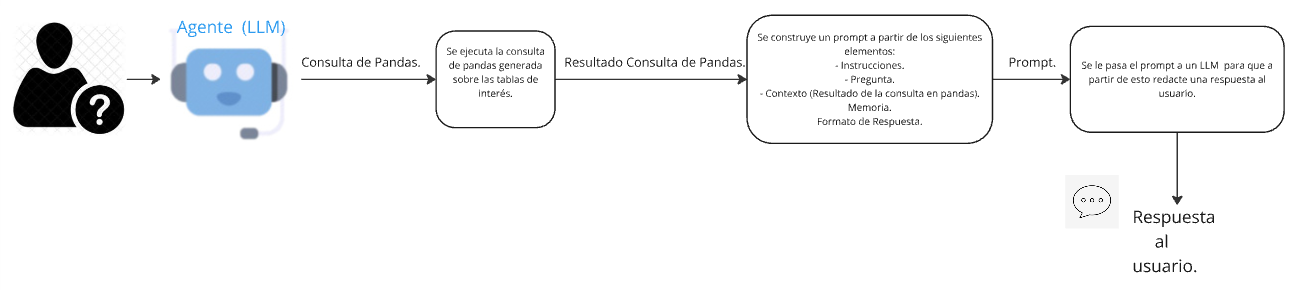

In [ ]:
eventos_df=pd.read_pickle("/content/Eventos_transformador.pkl")
eventos_df

,evento,equipo_ope,tipo_equi_ope,cto_equi_ope,tipo_elemento,inicio,fin,duracion_h,tipo_duracion,causa,...,TIPO_SUB,FECHA,GRUPO015,FECHA_ACT,KVA,KV1,LONGITUD,LATITUD,DEP,MUN
0,7549915,O23523,transformador,BOA23L12,TFD,2019-01-01 06:50:15,2019-01-01 09:10:31,2.337778,> 3 min,Causa desconocida,...,Subestaciones de distribución tipo poste,2019-01,32.0,2017-07,5.0,7.621,-75.948880,4.945180,RISARALDA,BALBOA
1,7549924,L13557,transformador,DON23L13,TFD,2019-01-01 00:00:01,2019-01-01 11:25:00,11.416389,> 3 min,Falla activo nivel 1 propiedad particular,...,Subestaciones de distribución tipo poste,2019-01,33.0,2005-10,5.0,13.200,-74.837784,5.478122,CALDAS,VICTORIA
2,7549940,W10256,transformador,BUM23L12,TFD,2019-01-01 10:19:13,2019-01-01 12:18:01,1.980000,> 3 min,Causa desconocida,...,Subestaciones de distribución tipo poste,2019-01,32.0,2004-09,15.0,7.621,-75.847935,5.196622,RISARALDA,BELÉN DE UMBRÍA
3,7549966,W55768,transformador,RIO23L14,TFD,2019-01-01 09:19:47,2019-01-01 12:50:16,3.508056,> 3 min,Árbol o rama sobre redes del SDL,...,Subestaciones de distribución tipo poste,2019-01,33.0,2017-12,25.0,7.621,-75.691988,5.486376,CALDAS,RIOSUCIO
4,7549968,O23660,transformador,BOA23L12,TFD,2019-01-01 11:35:25,2019-01-01 11:52:25,0.283333,> 3 min,Mantenimiento preventivo sobre las redes,...,Subestaciones de distribución tipo poste,2019-01,32.0,1899-12,10.0,7.621,-75.921015,4.964977,RISARALDA,SANTUARIO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68200,8272912,E12352,transformador,VCT23L13,TFD,2024-06-30 09:36:04,2024-06-30 17:00:54,7.413889,> 3 min,Falla en transformador de distribución o sus e...,...,Subestaciones de distribución tipo poste,2024-06,33.0,2023-02,10.0,7.621,-74.950447,5.270715,CALDAS,VICTORIA
68201,8272914,L11309,transformador,DON23L14,TFD,2024-06-30 13:30:11,2024-06-30 17:30:28,4.004722,> 3 min,Falla en postes y/o crucetas en el SDL,...,Subestaciones de distribución tipo poste,2024-06,33.0,2015-01,10.0,13.200,-74.844042,5.464336,CALDAS,VICTORIA
68202,8272918,D14083,transformador,ROS23L19,TFD,2024-06-30 14:57:50,2024-06-30 17:20:50,2.383333,> 3 min,Condiciones atmosféricas,...,Subestaciones de distribución tipo poste,2024-06,33.0,2015-01,37.5,13.200,-75.694873,4.874553,RISARALDA,DOSQUEBRADAS
68203,8272932,N10075,transformador,NRA23L12,TFD,2024-06-30 17:38:13,2024-06-30 18:37:27,0.987222,> 3 min,Causa desconocida,...,Subestaciones de distribución tipo poste,2024-06,22.0,2009-08,30.0,13.200,-75.518050,5.165072,CALDAS,NEIRA


In [ ]:
from getpass import getpass #Para ingresar la API KEY de OPEN AI
import os #Para cargar la API en las variables de entorno de la máquina
OPENAI_API_KEY = getpass('Enter the secret value: ')
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY

##Contextualizando al Agente Inteligente A partir de Ejemplos de la Data:

In [ ]:
agent = create_pandas_dataframe_agent(
        ChatOpenAI(temperature=0, model="gpt-3.5-turbo"),
        eventos_df,
        verbose=True,
        agent_type="openai-functions",#prefix=descripcion_df,  # Añade la descripción al inicio del prompt #suffix=suffix_instrucciones.format(path_plot=path_plot),
        allow_dangerous_code=True,
        include_df_in_prompt=True,  # Incluye las primeras filas del DataFrame en el prompt
        number_of_head_rows=5)

query="Cuantas interrupciones han habido en cada año. Respondeme siempre en español."
response=agent.invoke(query)["output"]

/tmp/ipython-input-878/3702983797.py:2: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the `langchain-openai package and should be used instead. To use it run `pip install -U `langchain-openai` and import as `from `langchain_openai import ChatOpenAI``.
  ChatOpenAI(temperature=0, model="gpt-3.5-turbo"),


ValidationError: 1 validation error for ChatOpenAI
  Value error, Did not find openai_api_key, please add an environment variable `OPENAI_API_KEY` which contains it, or pass `openai_api_key` as a named parameter. [type=value_error, input_value={'temperature': 0, 'model...ne, 'http_client': None}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error

In [ ]:
response

#Contextualizando al Agente Inteligente apartir de la Descripción de la Data:

In [ ]:
eventos_df.columns

In [ ]:
head_df = eventos_df.head(5).to_string(index=False)

descripcion_df="""
Este DataFrame contiene información acerca de interrupciones o eventos presentadas en redes eléctricas de media tensión,
más específicamente en tres tipos de equipos: Tranformadores, interruptores y tramos de linea (tramos de red).

Las columnas incluyen:
- **Evento**: Id de la interrupción o el evento.
- **equipo_ope**: Código del equipo en el que ocurrió la interrupción.
- **tipo_equi_ope**: Me indica si la interrupción ocurrió sobre un Transformador, o sobre un interruptor o sobre un tramo de linea, es decir que tiene solo tres posibles valores.
- **cto_equi_ope**: Código del circuito al que pertenece el equipo en el cual se dió la interrupción.
- **tipo_elemento**: Capacidad en Kilo Voltios del equipo en el cual ocurrió la interrupción, tiene 4 posibles valores: 33, 13.2, TFD y TFP
- **inicio**: Fecha y hora del inicio del evento o interrupción.
- **fin**: Fecha y hora de la finalización del evento o interrupción.
- **duracion_h**: Duración en horas del evento o interrupción.
- **tipo_duracion**: Variable categórica que indica si ele vento duró más de tres minutos o no; por tanto, tiene dos posibles valores: > 3 min y <= 3 min
- **causa**: Causa del evento o interrupción.
- **CNT_TRAFOS_AFEC**: Cantidad de transformadores afectados en la interrupción o evento.
- **cnt_usus**: Cantidad de usuarios afectados por la interrupción o evento.
- **SAIDI**: Indicador que mide el promedio de la duración en horas de la interrupción por usuario.
- **SAIFI**: Indicador que mide el promedio de cantidad de interrupciones por usuario.
- **PHASES**: Número de fases del equipo en el que ocurrió la interrupción; por tanto tiene 3 posibles valores: 3., 1., 2.
- **FPARENT**: Código del circuito que contiene el equipo en donde se presentó la interrupción.
- **FECHA**: Fecha en la que se presentó el evento o interrupción.
- **LONGITUD**: Longitud geográfica de la ubicación del equipo en el que se presentó la interrupción o evento.
- **LATITUD**: Latiud geográfica de la ubicación del equipo en el que se presentó la interrupción o evento.
- **DEP**: Departamento en donde se presentó la interrupción o evento.
- **MUN**: Municipio en donde se presentó la interrupción o evento.
"""

agent = create_pandas_dataframe_agent(
        ChatOpenAI(temperature=0, model="gpt-3.5-turbo"),
        eventos_df,
        verbose=True,
        agent_type="openai-functions",
        prefix=descripcion_df,  # Añade la descripción al inicio del prompt #suffix=suffix_instrucciones.format(path_plot=path_plot),
        allow_dangerous_code=True)

query="Cuantas interrupciones son superiores a 2 horas por cada año. Respondeme siempre en español."
response=agent.invoke(query)["output"]

In [ ]:
response

#Generando Gráficos apartir del Agente Inteligente:

In [ ]:
query="Construye un gráfico en el cual muestres la cantidad de interrupciones por cada departamento"
path_plot="/content/image.jpg"
prompt=f"""{query}. Construye el gráfico de la forma más estética posible para mostrar a un usuario.
    Puedes utilizar los siguientes colores: verde y gris en diferentes tonalidades (si es necesario, utiliza más colores).
    Además, los títulos y ejes de los gráficos deben estar en español.
    Guarda la imagen en la ruta relativa {path_plot}.
    No ejecutes el comando plt.show().
    Siempre ejecuta el comando plt.tight_layout()."""

agent = create_pandas_dataframe_agent(
        ChatOpenAI(temperature=0, model="gpt-3.5-turbo"),
        eventos_df,
        verbose=True,
        agent_type="openai-functions",#prefix=descripcion_df,  # Añade la descripción al inicio del prompt #suffix=suffix_instrucciones.format(path_plot=path_plot),
        allow_dangerous_code=True,
        include_df_in_prompt=True,  # Incluye las primeras filas del DataFrame en el prompt
        number_of_head_rows=5)

response=agent.invoke(prompt)["output"]

In [ ]:
response